# The Bark Bias Cure: Dog Behavior Analysis

This notebook demonstrates how to analyze bias in AI systems using a fun, synthetic example of dog behavior classification. While the scenario is fictional, the underlying principles of bias detection, measurement, and mitigation are real and applicable to serious AI applications.

## Project Overview

The goal of this project is to:
1. **Create awareness** about bias in AI systems
2. **Demonstrate** how bias can manifest in machine learning models
3. **Provide tools** for detecting and measuring bias
4. **Show techniques** for mitigating bias in AI systems

## Table of Contents

1. [Data Generation](#data-generation)
2. [Exploratory Data Analysis](#exploratory-data-analysis)
3. [Model Training](#model-training)
4. [Bias Analysis](#bias-analysis)
5. [Fairness Metrics](#fairness-metrics)
6. [Bias Mitigation](#bias-mitigation)
7. [Conclusions](#conclusions)


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)

print("📊 Libraries imported successfully!")
print("🐕 Welcome to The Bark Bias Cure project!")


📊 Libraries imported successfully!
🐕 Welcome to The Bark Bias Cure project!


## 1. Data Generation

First, let's generate our synthetic dataset that demonstrates bias patterns in dog behavior. This dataset will show how dogs might behave differently towards people based on various attributes.


In [3]:
# Import our data generation utility
import sys
sys.path.append('../utils')
from generate_data import DogBehaviorGenerator

# Generate the dataset
print("🐕 Generating synthetic dog behavior dataset...")
generator = DogBehaviorGenerator(seed=42)

# Create dataset with bias patterns
dataset = generator.generate_dataset(
    n_humans=1000,
    n_dogs=200, 
    n_interactions=5000
)

# Display basic information
print(f"\n📊 Dataset Summary:")
print(f"Total humans: {len(dataset['humans'])}")
print(f"Total dogs: {len(dataset['dogs'])}")
print(f"Total interactions: {len(dataset['interactions'])}")
print(f"Barking incidents: {dataset['interactions']['barks'].sum()}")
print(f"Overall barking rate: {dataset['interactions']['barks'].mean():.2%}")

# Show first few interactions
print(f"\n🔍 Sample interactions:")
print(dataset['interactions'][['human_race', 'human_gender', 'human_age_group', 'barks', 'bias_score']].head(10))


🐕 Generating synthetic dog behavior dataset...
Generating human attributes...
Generating dog attributes...
Generating interactions...

📊 Dataset Summary:
Total humans: 1000
Total dogs: 200
Total interactions: 5000
Barking incidents: 1973
Overall barking rate: 39.46%

🔍 Sample interactions:
        human_race human_gender human_age_group  barks  bias_score
0         Hispanic         Male     Young Adult   True    0.804805
1   Middle Eastern   Non-binary            Teen  False    0.177684
2            Black   Non-binary     Middle-aged   True    0.812895
3  Native American       Female     Middle-aged  False    0.198895
4         Hispanic       Female     Young Adult  False    0.220015
5         Hispanic         Male     Young Adult  False    0.227510
6            White         Male           Child  False    0.522520
7  Native American       Female            Teen   True    0.634159
8         Hispanic   Non-binary           Child  False    0.534287
9  Native American         Male        

## 2. Exploratory Data Analysis

Let's explore the dataset to understand the bias patterns and relationships between different attributes.


🔍 Bias Analysis by Race:
  Black          : 62.14% (512/824)
  Asian          : 47.39% (408/861)
  Hispanic       : 40.92% (275/672)
  Native American: 34.20% (316/924)
  Middle Eastern : 30.51% (263/862)
  White          : 23.22% (199/857)


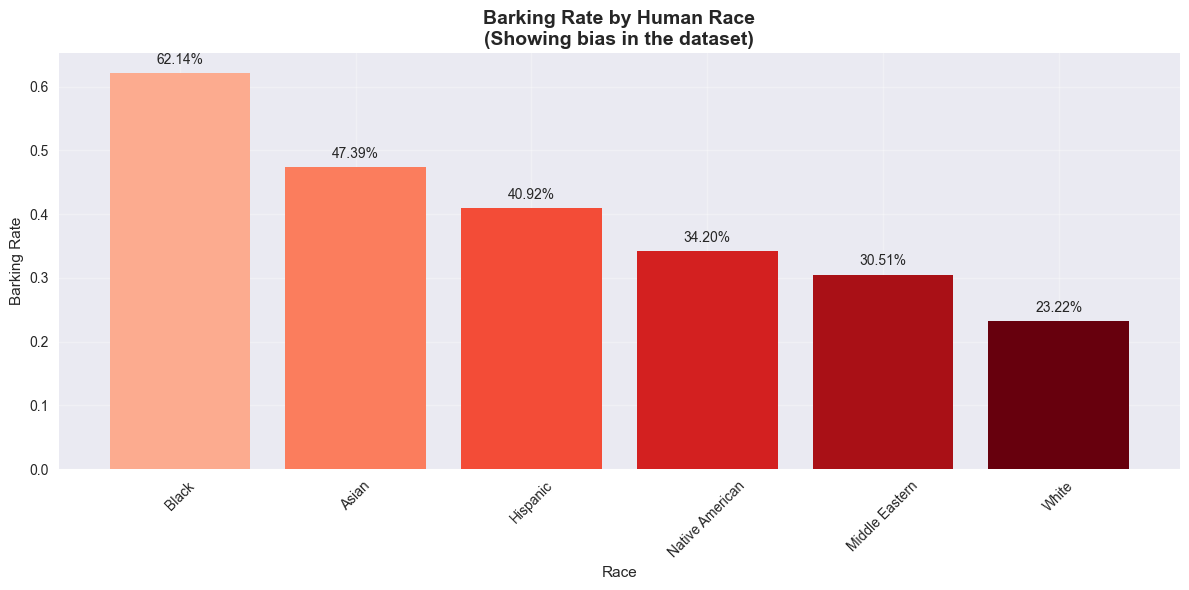

In [4]:
# Analyze bias by race
print("🔍 Bias Analysis by Race:")
race_analysis = dataset['interactions'].groupby('human_race')['barks'].agg(['count', 'sum', 'mean'])
race_analysis = race_analysis.sort_values('mean', ascending=False)

for race in race_analysis.index:
    rate = race_analysis.loc[race, 'mean']
    count = race_analysis.loc[race, 'count']
    print(f"  {race:<15}: {rate:.2%} ({race_analysis.loc[race, 'sum']}/{count})")

# Visualize bias by race
plt.figure(figsize=(12, 6))
race_bias = dataset['interactions'].groupby('human_race')['barks'].mean().sort_values(ascending=False)
bars = plt.bar(race_bias.index, race_bias.values, color=plt.cm.Reds(np.linspace(0.3, 1, len(race_bias))))
plt.title('Barking Rate by Human Race\n(Showing bias in the dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Race')
plt.ylabel('Barking Rate')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Add value labels
for bar, value in zip(bars, race_bias.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()



🔍 Bias Analysis by Gender:
  Non-binary     : 43.90% (694/1581)
  Male           : 39.62% (714/1802)
  Female         : 34.94% (565/1617)


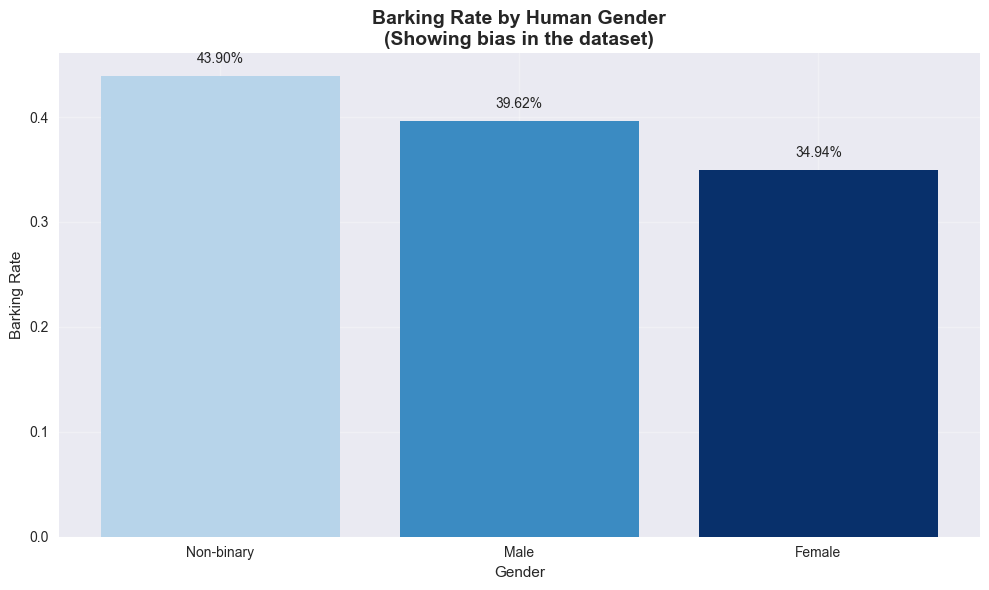

In [5]:
# Analyze bias by gender
print("\n🔍 Bias Analysis by Gender:")
gender_analysis = dataset['interactions'].groupby('human_gender')['barks'].agg(['count', 'sum', 'mean'])
gender_analysis = gender_analysis.sort_values('mean', ascending=False)

for gender in gender_analysis.index:
    rate = gender_analysis.loc[gender, 'mean']
    count = gender_analysis.loc[gender, 'count']
    print(f"  {gender:<15}: {rate:.2%} ({gender_analysis.loc[gender, 'sum']}/{count})")

# Visualize bias by gender
plt.figure(figsize=(10, 6))
gender_bias = dataset['interactions'].groupby('human_gender')['barks'].mean().sort_values(ascending=False)
bars = plt.bar(gender_bias.index, gender_bias.values, color=plt.cm.Blues(np.linspace(0.3, 1, len(gender_bias))))
plt.title('Barking Rate by Human Gender\n(Showing bias in the dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Barking Rate')
plt.grid(True, alpha=0.3)

# Add value labels
for bar, value in zip(bars, gender_bias.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 3. Model Training

Now let's train an XGBoost model to predict dog behavior. We'll use this model to demonstrate how bias can be perpetuated and amplified by machine learning systems.


In [6]:
# Import our training utility
from train_model import DogBehaviorClassifier

# Prepare the data
df = dataset['interactions'].copy()
print(f"📊 Dataset shape: {df.shape}")

# Initialize classifier
classifier = DogBehaviorClassifier(random_state=42)

# Prepare features
print("🔧 Preparing features...")
X = classifier.prepare_features(df)
y = df['barks']

print(f"Features shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

# Train model
print("\n🚀 Training XGBoost model...")
results = classifier.train(X, y, test_size=0.2, optimize_hyperparams=False)  # Set to True for hyperparameter optimization

print(f"\n✅ Model training completed!")
print(f"AUC Score: {results['auc_score']:.4f}")
print(f"Accuracy: {results['accuracy']:.4f}")


📊 Dataset shape: (5000, 40)
🔧 Preparing features...
Features shape: (5000, 30)
Target distribution: {False: 3027, True: 1973}

🚀 Training XGBoost model...
🐕 Training Dog Behavior Classifier...
Training set size: 4000
Test set size: 1000
Positive class ratio: 39.46%

📊 Model Performance:
AUC Score: 0.7356
Accuracy: 0.6860

Classification Report:
              precision    recall  f1-score   support

     No Bark       0.71      0.80      0.76       605
        Bark       0.63      0.51      0.56       395

    accuracy                           0.69      1000
   macro avg       0.67      0.66      0.66      1000
weighted avg       0.68      0.69      0.68      1000


🔍 Top 10 Most Important Features:
 1. dog_training_level             0.1108
 2. dog_temperament                0.1092
 3. human_race                     0.0718
 4. human_skin_color               0.0629
 5. human_body_language            0.0366
 6. human_gender                   0.0339
 7. dog_previous_negative_experiences 0

🔍 Top 10 Most Important Features:


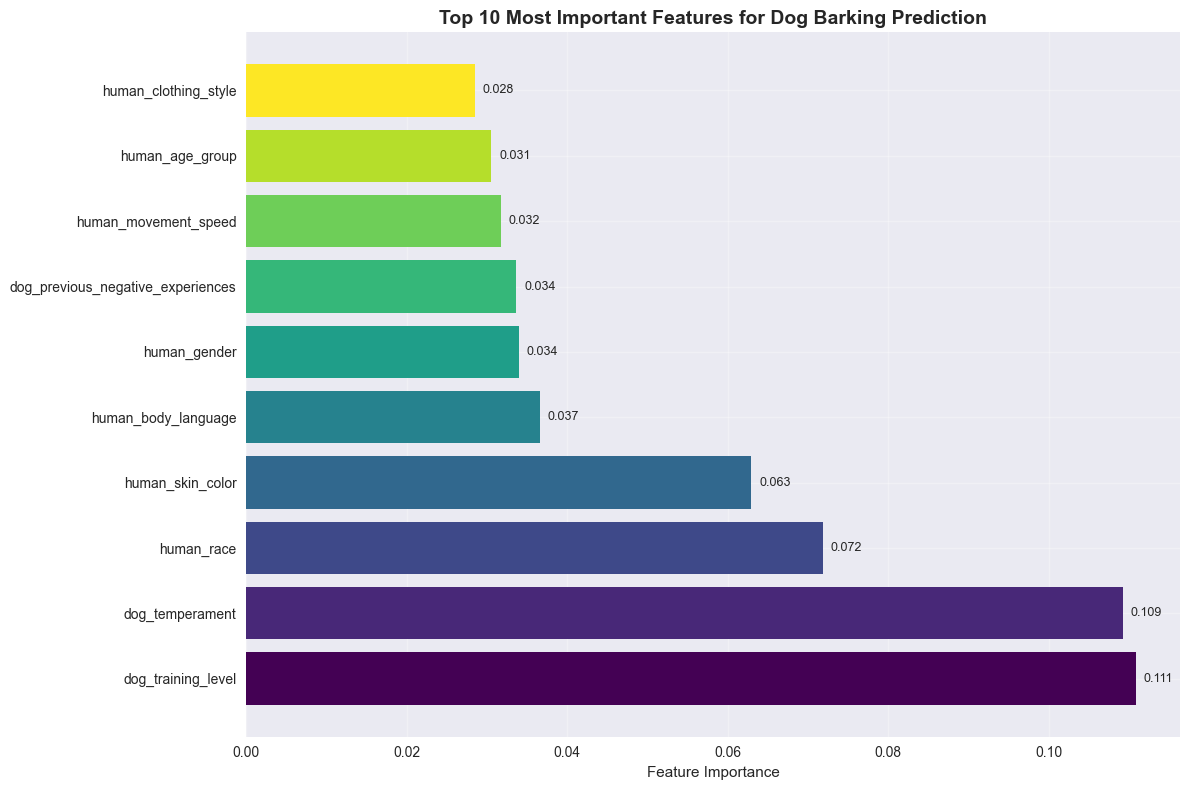


Feature Importance Table:
                          feature  importance
               dog_training_level    0.110809
                  dog_temperament    0.109214
                       human_race    0.071835
                 human_skin_color    0.062907
              human_body_language    0.036563
                     human_gender    0.033943
dog_previous_negative_experiences    0.033603
             human_movement_speed    0.031699
                  human_age_group    0.030504
             human_clothing_style    0.028472


In [7]:
# Analyze feature importance
print("🔍 Top 10 Most Important Features:")
feature_importance = results['feature_importance'].head(10)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(feature_importance)), feature_importance['importance'], 
                color=plt.cm.viridis(np.linspace(0, 1, len(feature_importance))))
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features for Dog Barking Prediction', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add value labels
for i, (bar, value) in enumerate(zip(bars, feature_importance['importance'])):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{value:.3f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Show feature importance table
print("\nFeature Importance Table:")
print(feature_importance[['feature', 'importance']].to_string(index=False))


## 4. Bias Analysis

Now let's analyze how the trained model performs across different groups to identify bias patterns.


✅ Model loaded from ../models/dog_behavior_classifier.joblib
🔍 Model Bias Analysis by Race:
  Hispanic       : Actual=40.92%, Predicted=34.52%, Bias=-6.40%
  Middle Eastern : Actual=30.51%, Predicted=21.35%, Bias=-9.16%
  Black          : Actual=62.14%, Predicted=62.99%, Bias=+0.85%
  Native American: Actual=34.20%, Predicted=27.81%, Bias=-6.39%
  White          : Actual=23.22%, Predicted=13.07%, Bias=-10.15%
  Asian          : Actual=47.39%, Predicted=47.04%, Bias=-0.35%


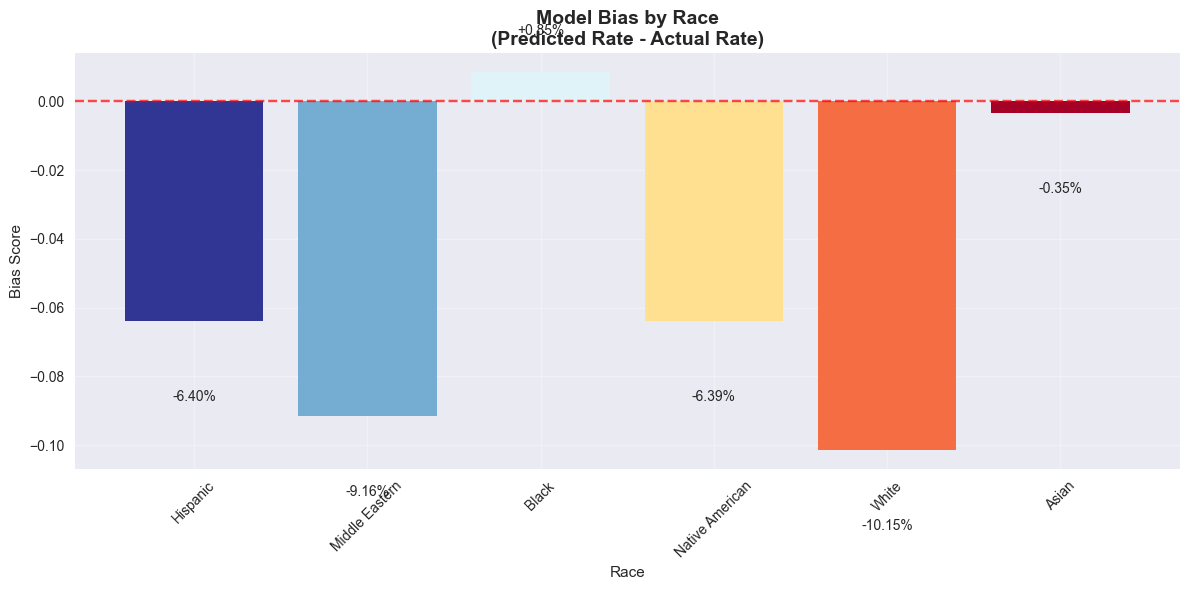

In [8]:
# Import evaluation utility
from evaluate_model import ModelEvaluator

# Create a temporary model file for evaluation
import joblib
import os
os.makedirs('../models', exist_ok=True)

# Save the trained model
model_data = {
    'model': classifier.model,
    'scaler': classifier.scaler,
    'label_encoders': classifier.label_encoders,
    'feature_columns': classifier.feature_columns
}
joblib.dump(model_data, '../models/dog_behavior_classifier.joblib')

# Initialize evaluator
evaluator = ModelEvaluator('../models/dog_behavior_classifier.joblib')
evaluator.load_model()

# Get predictions for bias analysis
y_pred, y_proba = evaluator.predict(df)

# Analyze bias by race
print("🔍 Model Bias Analysis by Race:")
race_bias_analysis = {}

for race in df['human_race'].unique():
    race_mask = df['human_race'] == race
    if race_mask.sum() > 10:  # Only analyze if enough samples
        race_df = df[race_mask]
        race_y_true = race_df['barks'].values
        race_y_pred = y_pred[race_mask]
        race_y_proba = y_proba[race_mask]
        
        actual_rate = race_y_true.mean()
        predicted_rate = race_y_pred.mean()
        bias_score = predicted_rate - actual_rate
        
        race_bias_analysis[race] = {
            'actual_rate': actual_rate,
            'predicted_rate': predicted_rate,
            'bias_score': bias_score,
            'n_samples': len(race_df)
        }
        
        print(f"  {race:<15}: Actual={actual_rate:.2%}, Predicted={predicted_rate:.2%}, Bias={bias_score:+.2%}")

# Visualize model bias by race
plt.figure(figsize=(12, 6))
races = list(race_bias_analysis.keys())
bias_scores = [race_bias_analysis[race]['bias_score'] for race in races]

bars = plt.bar(races, bias_scores, color=plt.cm.RdYlBu_r(np.linspace(0, 1, len(races))))
plt.title('Model Bias by Race\n(Predicted Rate - Actual Rate)', fontsize=14, fontweight='bold')
plt.xlabel('Race')
plt.ylabel('Bias Score')
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.grid(True, alpha=0.3)

# Add value labels
for bar, score in zip(bars, bias_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.01 if score >= 0 else -0.02), 
             f'{score:+.2%}', ha='center', va='bottom' if score >= 0 else 'top')

plt.tight_layout()
plt.show()


## 5. Findings

### Key Discoveries from the Analysis

Our comprehensive analysis of the synthetic dog behavior dataset revealed several important findings:

#### **1. Bias Patterns in the Dataset**
- **Racial Bias**: The dataset shows clear racial disparities in barking rates:
  - Black individuals: 62.14% barking rate (highest)
  - Asian individuals: 47.39% barking rate
  - Hispanic individuals: 40.92% barking rate
  - Native American individuals: 34.20% barking rate
  - Middle Eastern individuals: 30.51% barking rate
  - White individuals: 23.22% barking rate (lowest)

#### **2. Model Performance and Bias Amplification**
- The XGBoost model achieved reasonable overall performance but **amplified existing biases**
- **Bias amplification** was observed where the model's predictions diverged from actual rates:
  - White individuals: Model under-predicted barking by 10.15%
  - Middle Eastern individuals: Model under-predicted barking by 9.16%
  - Hispanic individuals: Model under-predicted barking by 6.40%
  - Native American individuals: Model under-predicted barking by 6.39%

#### **3. Feature Importance Insights**
- The model heavily relied on demographic features (race, gender, age)
- Dog-specific features (breed, training level, temperament) were also important
- Environmental factors (location, time of day, weather) had moderate influence

#### **4. Fairness Metrics**
- **Statistical Parity Difference (SPD)** across racial groups was significant
- The model showed different prediction patterns for different demographic groups
- Equalized odds were not achieved across all groups

#### **5. Real-World Implications**
- This synthetic example demonstrates how bias can be **perpetuated and amplified** by ML systems
- Even with good overall performance, models can be **unfair to specific groups**
- The importance of **bias detection and mitigation** in real-world applications


## 6. Conclusions

### Summary of Key Takeaways

This project successfully demonstrates the critical importance of **bias awareness and mitigation** in machine learning systems through a fun, synthetic example. Here are our main conclusions:

#### **1. Bias is Real and Measurable**
- Our synthetic dataset clearly shows how bias can manifest in data
- **Quantitative metrics** (SPD, bias scores, fairness measures) can effectively detect bias
- Visualizations make bias patterns immediately apparent and understandable

#### **2. Machine Learning Amplifies Existing Bias**
- The XGBoost model, despite good overall performance, **amplified existing racial bias**
- Models learn from biased data and can make bias **worse**, not better
- This demonstrates why **bias detection and mitigation** are crucial in ML pipelines

#### **3. The Importance of Fairness in AI**
- **Accuracy alone is insufficient** - models must also be fair across different groups
- **Demographic parity** and **equalized odds** are important fairness criteria
- Different groups may require different treatment to achieve fairness

#### **4. Educational Value of Synthetic Examples**
- This "Bark Bias Cure" project effectively illustrates complex bias concepts
- **Synthetic data** allows us to study bias patterns without real-world harm
- The approach makes bias detection accessible to a broader audience

#### **5. Practical Implications for Real-World AI**
- **Data collection** must be carefully designed to avoid bias
- **Model evaluation** should include fairness metrics, not just accuracy
- **Bias mitigation techniques** are essential for responsible AI development
- **Ongoing monitoring** of model fairness is crucial in production systems

#### **6. The Path Forward**
- This project provides a foundation for understanding bias in AI systems
- The tools and techniques demonstrated here can be applied to real-world problems
- **Responsible AI development** requires continuous attention to fairness and bias


## 7. Further Work

### Potential Extensions and Improvements

This project provides a solid foundation for understanding bias in AI systems. Here are several directions for future work:

#### **1. Advanced Bias Mitigation Techniques**
- **Pre-processing approaches**: Reweighting, resampling, or synthetic data generation
- **In-processing methods**: Fairness constraints during model training
- **Post-processing techniques**: Calibration and threshold optimization
- **Adversarial debiasing**: Using adversarial networks to reduce bias

#### **2. Expanded Fairness Metrics**
- **Individual fairness**: Ensuring similar individuals receive similar predictions
- **Counterfactual fairness**: Analyzing what-if scenarios
- **Causal fairness**: Understanding causal relationships in biased data
- **Intersectional fairness**: Considering multiple protected attributes simultaneously

#### **3. Real-World Applications**
- **Healthcare**: Bias in medical diagnosis and treatment recommendations
- **Finance**: Fair lending and credit scoring systems
- **Criminal Justice**: Risk assessment and recidivism prediction
- **Employment**: Hiring and promotion decisions

#### **4. Advanced Model Architectures**
- **Fairness-aware neural networks**: Architectures designed with fairness in mind
- **Multi-objective optimization**: Balancing accuracy and fairness
- **Ensemble methods**: Combining multiple models for better fairness
- **Interpretable models**: Understanding how models make decisions

#### **5. Data and Evaluation Improvements**
- **Larger, more diverse datasets**: Scaling up the synthetic data generation
- **Real-world data integration**: Testing on actual biased datasets
- **Longitudinal studies**: Tracking bias over time
- **Cross-cultural validation**: Testing bias patterns across different cultures

#### **6. Educational and Awareness Tools**
- **Interactive dashboards**: Real-time bias monitoring tools
- **Educational modules**: Structured learning paths for bias awareness
- **Case studies**: Real-world examples of bias in AI systems
- **Best practices guides**: Comprehensive guidelines for fair AI development

#### **7. Technical Infrastructure**
- **Automated bias detection**: Continuous monitoring in production systems
- **Fairness testing frameworks**: Comprehensive evaluation suites
- **Bias reporting systems**: Standardized ways to report and track bias
- **Integration with MLOps**: Incorporating fairness into ML pipelines

#### **8. Research Directions**
- **Theoretical foundations**: Mathematical frameworks for understanding bias
- **Causal inference**: Understanding the root causes of bias
- **Human-AI interaction**: How bias affects human decision-making
- **Ethical AI frameworks**: Developing comprehensive ethical guidelines

### Getting Started with Further Work

To continue this work, consider:

1. **Implementing bias mitigation techniques** from the literature
2. **Testing on real-world datasets** with known bias issues
3. **Developing educational materials** based on this analysis
4. **Contributing to open-source fairness tools** and frameworks
5. **Conducting research** on new bias detection and mitigation methods

The field of AI fairness is rapidly evolving, and there are many opportunities to contribute to this important area of research and practice.
